# Flex Scenario Curve Generator

This notebook generates flex (demand response) multipliers for a segment.

**Flex curves** flatten the demand profile:
- Lower peaks (multiplier < 1 when demand > mean)
- Raise valleys (multiplier > 1 when demand < mean)
- Preserve yearly totals

**Output**: `curves.parquet` with columns `[timestamp, index, value]`

**Requires**: Base scenario data must exist in `generator/output/base/`

**Usage**:
1. Ensure base generation has been run (behovskartan2.ipynb)
2. Configure the parameters below
3. Run all cells
4. Verify the output plot

In [1]:
# ============================================================
# CONFIGURATION - Edit these values
# ============================================================

# Segment name
SEGMENT = "datacenters"  # Change this for each segment

# Base scenario to derive flex curves from
BASE_SCENARIO = "Beslutad Policy"

# Time range (must match base generation)
START_YEAR = 2025
END_YEAR = 2050

# Flex scenario values
# Each entry is: (index, flex_factor, label)
# - index: The scenario parameter index (0 = baseline, not stored)
# - flex_factor: How much to flatten (1.0 = no change, 0.0 = completely flat)
#   - 0.8 = 20% flattening (peaks reduced 20%, valleys raised 20%)
#   - 0.6 = 40% flattening
# - label: Human-readable label

SCENARIOS = [
    (1, 0.8, "Low Flex (20% flattening)"),
    (2, 0.6, "High Flex (40% flattening)"),
]

# Note: Index 0 is always baseline (no file needed, API uses base data)
print(f"Segment: {SEGMENT}")
print(f"Base scenario: {BASE_SCENARIO}")
print(f"Period: {START_YEAR}-{END_YEAR}")
print(f"Scenarios: {len(SCENARIOS)}")
for idx, flex, label in SCENARIOS:
    print(f"  Index {idx}: {label} (flex_factor = {flex})")

Segment: datacenters
Base scenario: Beslutad Policy
Period: 2025-2050
Scenarios: 2
  Index 1: Low Flex (20% flattening) (flex_factor = 0.8)
  Index 2: High Flex (40% flattening) (flex_factor = 0.6)


In [2]:
# Setup paths
from pathlib import Path
import pandas as pd
import numpy as np

NOTEBOOK_DIR = Path.cwd()
GENERATOR_PATH = NOTEBOOK_DIR.parent.parent.parent  # input/scenarios/{segment}_flex -> generator
OUTPUT_PATH = GENERATOR_PATH / 'output'
BASE_PATH = OUTPUT_PATH / 'base' / BASE_SCENARIO / SEGMENT / 'data.parquet'

print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Generator path: {GENERATOR_PATH}")
print(f"Base data path: {BASE_PATH}")
print(f"Base data exists: {BASE_PATH.exists()}")

if not BASE_PATH.exists():
    raise FileNotFoundError(
        f"Base data not found at {BASE_PATH}\n"
        f"Please run behovskartan2.ipynb first to generate base scenarios."
    )

Notebook directory: /home/viktor/code/behovskartan/generator/input/scenarios/datacenters_flex
Generator path: /home/viktor/code/behovskartan/generator
Base data path: /home/viktor/code/behovskartan/generator/output/base/Beslutad Policy/datacenters/data.parquet
Base data exists: True


In [3]:
# Load base segment data
print(f"Loading base data for {SEGMENT}...")

df = pd.read_parquet(BASE_PATH)
print(f"Loaded {len(df):,} rows")
print(f"Columns: {list(df.columns)}")
print(f"Time range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Geographies: {df['geography'].nunique()}")

Loading base data for datacenters...
Loaded 4,785,984 rows
Columns: ['timestamp', 'value', 'geography', 'segment', 'scenario_id']
Time range: 2025-01-01 00:00:00 to 2050-12-31 23:00:00
Geographies: 21


In [4]:
# Compute national profile (sum across all geographies)
print("Computing national profile...")

national = df.groupby('timestamp')['value'].sum().reset_index()
national = national.set_index('timestamp').sort_index()

# Add year column for yearly mean calculation
national['year'] = national.index.year

print(f"National profile: {len(national):,} timestamps")
print(f"Years: {national['year'].min()} to {national['year'].max()}")
print(f"Total demand: {national['value'].sum():,.2f} GWh")

Computing national profile...
National profile: 227,904 timestamps
Years: 2025 to 2050
Total demand: 172,998.66 GWh


In [5]:
# Compute yearly means
print("Computing yearly means...")

yearly_means = national.groupby('year')['value'].mean()
national['yearly_mean'] = national['year'].map(yearly_means)

print(f"\nYearly mean demand (GWh per hour):")
for year in [START_YEAR, 2030, 2040, END_YEAR]:
    if year in yearly_means.index:
        print(f"  {year}: {yearly_means[year]:.6f}")

Computing yearly means...

Yearly mean demand (GWh per hour):
  2025: 0.342466
  2030: 0.490868
  2040: 0.808288
  2050: 1.312794


In [6]:
# Generate flex multipliers for each scenario
print(f"Generating {len(SCENARIOS)} flex curves...")

all_curves = []

for idx, flex_factor, label in SCENARIOS:
    # Compute multiplier: (mean + flex * (value - mean)) / value
    # This flattens the profile toward the mean
    # flex_factor = 1.0 -> no change (multiplier = 1.0 everywhere)
    # flex_factor = 0.0 -> completely flat (value becomes mean)
    
    new_value = national['yearly_mean'] + flex_factor * (national['value'] - national['yearly_mean'])
    multiplier = new_value / national['value']
    
    # Handle edge cases (very small values)
    multiplier = multiplier.replace([np.inf, -np.inf], 1.0)
    multiplier = multiplier.fillna(1.0)
    
    curve_df = pd.DataFrame({
        'timestamp': national.index,
        'index': idx,
        'value': multiplier.values
    })
    
    all_curves.append(curve_df)
    
    # Show summary
    print(f"  Index {idx} ({label}):")
    print(f"    Multiplier range: {multiplier.min():.4f} to {multiplier.max():.4f}")
    print(f"    Mean multiplier: {multiplier.mean():.4f}")

# Combine all curves
result_df = pd.concat(all_curves, ignore_index=True)
print(f"\nTotal rows: {len(result_df):,}")
print(f"Unique indices: {sorted(result_df['index'].unique())}")

Generating 2 flex curves...
  Index 1 (Low Flex (20% flattening)):
    Multiplier range: 0.8585 to 1.1150
    Mean multiplier: 1.0582
  Index 2 (High Flex (40% flattening)):
    Multiplier range: 0.7169 to 1.2299
    Mean multiplier: 1.1165

Total rows: 455,808
Unique indices: [np.int64(1), np.int64(2)]


In [7]:
# Verify totals are preserved
print("Verifying yearly totals are preserved...\n")

original_yearly = national.groupby('year')['value'].sum()

for idx, flex_factor, label in SCENARIOS:
    # Apply multiplier to original values
    curve = result_df[result_df['index'] == idx].set_index('timestamp')['value']
    adjusted = national['value'] * curve
    adjusted_yearly = adjusted.groupby(national['year']).sum()
    
    # Compare
    diff_pct = ((adjusted_yearly - original_yearly) / original_yearly * 100).abs().max()
    status = "✓" if diff_pct < 0.01 else "✗"
    print(f"{status} Index {idx} ({label}): max difference = {diff_pct:.4f}%")

Verifying yearly totals are preserved...

✓ Index 1 (Low Flex (20% flattening)): max difference = 0.0000%
✓ Index 2 (High Flex (40% flattening)): max difference = 0.0000%


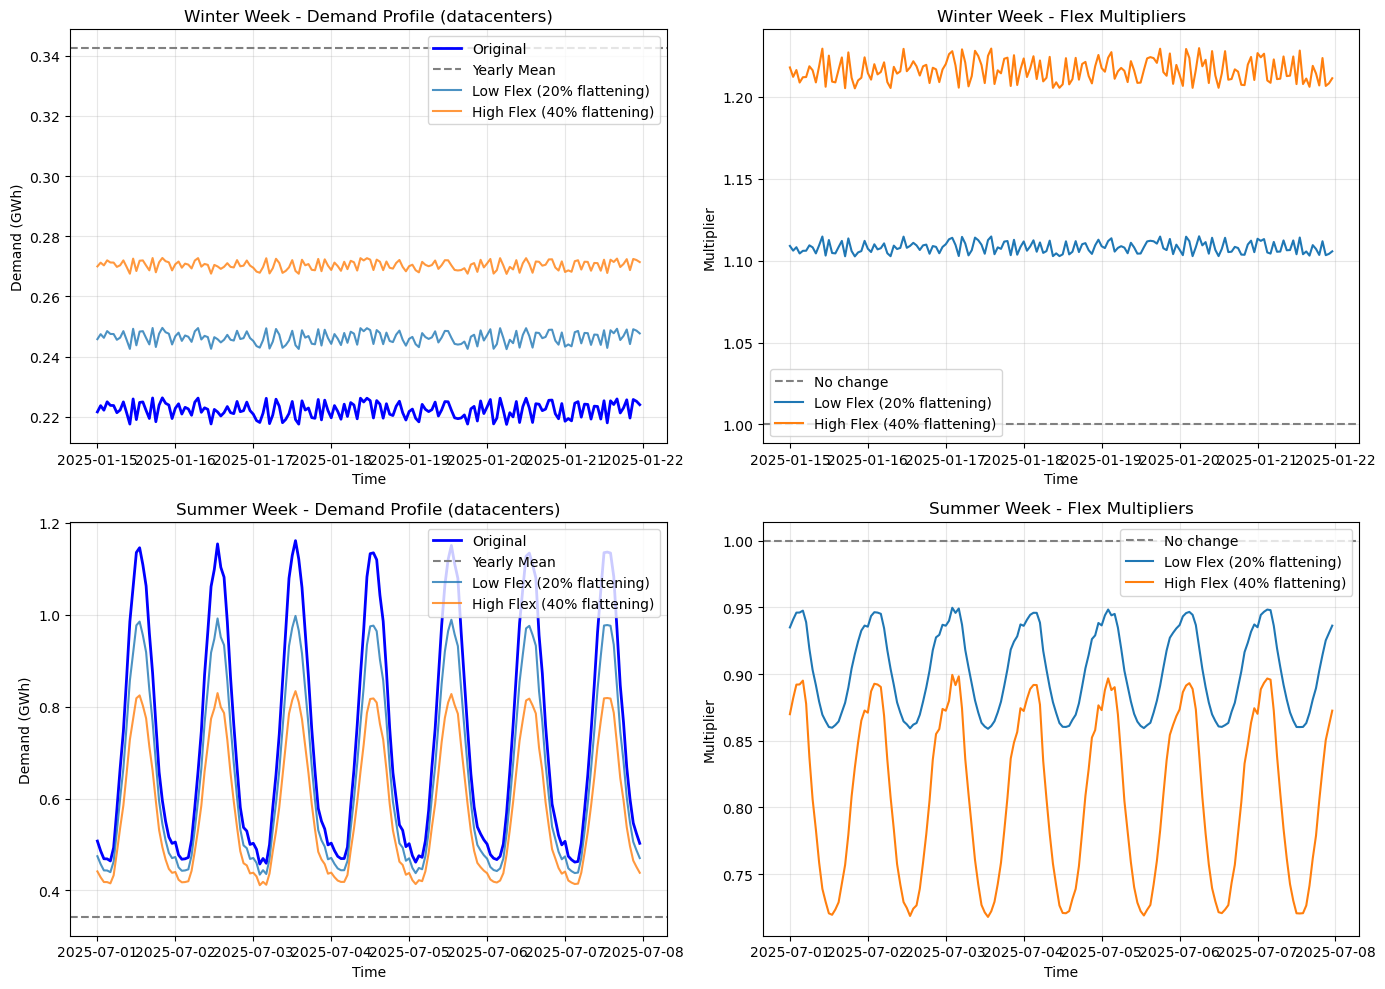

In [8]:
# Visualize the effect on one week of data
import matplotlib.pyplot as plt

# Pick a week in summer and winter
summer_start = pd.Timestamp(f"{START_YEAR}-07-01")
summer_end = summer_start + pd.Timedelta(days=7)

winter_start = pd.Timestamp(f"{START_YEAR}-01-15")
winter_end = winter_start + pd.Timedelta(days=7)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, (start, end, season) in enumerate([(winter_start, winter_end, "Winter"), (summer_start, summer_end, "Summer")]):
    mask = (national.index >= start) & (national.index < end)
    week_data = national[mask]
    
    # Left plot: Original vs flattened demand
    ax1 = axes[row, 0]
    ax1.plot(week_data.index, week_data['value'], label='Original', linewidth=2, color='blue')
    ax1.axhline(week_data['yearly_mean'].iloc[0], color='gray', linestyle='--', label='Yearly Mean')
    
    for idx, flex_factor, label in SCENARIOS:
        curve = result_df[result_df['index'] == idx].set_index('timestamp')['value']
        flattened = week_data['value'] * curve[mask]
        ax1.plot(week_data.index, flattened, label=label, linewidth=1.5, alpha=0.8)
    
    ax1.set_title(f"{season} Week - Demand Profile ({SEGMENT})")
    ax1.set_xlabel("Time")
    ax1.set_ylabel("Demand (GWh)")
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    
    # Right plot: Multipliers
    ax2 = axes[row, 1]
    ax2.axhline(1.0, color='gray', linestyle='--', label='No change')
    
    for idx, flex_factor, label in SCENARIOS:
        curve = result_df[result_df['index'] == idx].set_index('timestamp')['value']
        ax2.plot(week_data.index, curve[mask], label=label, linewidth=1.5)
    
    ax2.set_title(f"{season} Week - Flex Multipliers")
    ax2.set_xlabel("Time")
    ax2.set_ylabel("Multiplier")
    ax2.legend(loc='best')
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Write output
output_path = NOTEBOOK_DIR / "curves.parquet"

result_df.to_parquet(output_path, index=False)

print(f"Written: {output_path}")
print(f"Size: {output_path.stat().st_size / 1024 / 1024:.2f} MB")

# Verify
verify_df = pd.read_parquet(output_path)
print(f"\nVerification:")
print(f"  Rows: {len(verify_df):,}")
print(f"  Columns: {list(verify_df.columns)}")
print(f"  Indices: {sorted(verify_df['index'].unique())}")
print(f"  Time range: {verify_df['timestamp'].min()} to {verify_df['timestamp'].max()}")

Written: /home/viktor/code/behovskartan/generator/input/scenarios/datacenters_flex/curves.parquet
Size: 6.99 MB

Verification:
  Rows: 455,808
  Columns: ['timestamp', 'index', 'value']
  Indices: [np.int64(1), np.int64(2)]
  Time range: 2025-01-01 00:00:00 to 2050-12-31 23:00:00


In [10]:
# Summary table
print(f"\n{'='*60}")
print(f"SUMMARY: {SEGMENT}_flex curves")
print(f"{'='*60}")
print(f"\n{'Index':<8} {'Label':<30} {'Flex Factor':<12} {'Effect'}")
print("-" * 70)
print(f"{'0':<8} {'Baseline':<30} {'1.0':<12} {'No flattening'}")
for idx, flex, label in SCENARIOS:
    effect = f"{(1-flex)*100:.0f}% flattening"
    print(f"{idx:<8} {label:<30} {flex:<12} {effect}")
print(f"\nOutput: {output_path}")
print(f"\nNote: Multipliers are computed from {BASE_SCENARIO} national profile.")
print(f"      Same multipliers apply to all geographies.")


SUMMARY: datacenters_flex curves

Index    Label                          Flex Factor  Effect
----------------------------------------------------------------------
0        Baseline                       1.0          No flattening
1        Low Flex (20% flattening)      0.8          20% flattening
2        High Flex (40% flattening)     0.6          40% flattening

Output: /home/viktor/code/behovskartan/generator/input/scenarios/datacenters_flex/curves.parquet

Note: Multipliers are computed from Beslutad Policy national profile.
      Same multipliers apply to all geographies.
